# TC2034 | Actividad 3: K-Means
--- 
#### By: Laurie Camila Hernández Pacheco - A0128569

En esta notebook se trabaja con un tutorial para la creación e implementación de un modelo de *clustering* utilizando **K-Means**. El *clustering* basado en *k-means* es un método de aprendizaje no supervisado que se basa en agrupar los datos en *clusters*, grupos de datos que comparten similitudes. 

Se eligió el dataset de *Social Media Impact on Teen Mental Health*, que se encuentra en el archivo `Teen_Mental_Health_Dataset.csv`. Este dataset contiene un total de 13 columnas, que se listan y se describen a continuación: 

| Característica | Tipo de variable | Descripción |
|---------------|-----------------|----------|
| age | Numérica discreta | Edad del adolescente (en años) |
| gender | Categórica nominal | Género del individuo (male, female) |
| daily_social_media_hours | Numérica continua | Horas promedio diarias que pasa en redes sociales |
| platform_usage | Categórica nominal | Plataforma principal utilizada (Instagram, TikTok, Both) |
| sleep_hours | Numérica continua | Número de horas de sueño por noche |
| screen_time_before_sleep | Numérica continua | Tiempo (en horas) usando pantallas antes de dormir |
| academic_performance | Numérica continua | Indicador del rendimiento académico (escala numérica) |
| physical_activity | Numérica continua | Nivel de actividad física diaria (horas o índice) |
| social_interaction_level | Categórica ordinal | Nivel de interacción social (low, medium, high) |
| stress_level | Numérica discreta | Nivel de estrés (escala, por ejemplo 1–10) |
| anxiety_level | Numérica discreta | Nivel de ansiedad (escala, por ejemplo 1–10) |
| addiction_level | Numérica discreta | Nivel de adicción a redes sociales (escala) |
| depression_label | Binaria (categórica) | Indicador de depresión (0 = no, 1 = sí) |

Para este trabajo, se sigue un tutorial para la implementación de K-Means y diseño de una pipeline de estandarización y entrenamiento de los datos.


## 0. Setup 
Incialmente, se importan las librerías necesarias para el seguimiento del tutorial, junto con algunas adicionales para limpieza y manejo de datos: 

In [2]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## 1. Ejemplo de Uso con Blobs

Dentro del tutorial, se indica un ejemplo de uso utilizando `make_blobs` con el objetivo de visualizar el comportamiento del algoritmo de *K-Means*. A continuación se elabora dicho ejemplo. 

### 1.1 Manejo de Datos Blobs

Inicialmente se utiliza `make_blobs` para generar datos aleatorios y poder probar el modelo: 

In [3]:
features, true_labels = make_blobs(
    n_samples=200,
    centers=3,
    cluster_std=2.75,
    random_state=6767
)
print(f"Primeros 5 elementos: {features[:5]}")
print(f"True labels: {true_labels[:5]}")

Primeros 5 elementos: [[ 3.25242772 -2.67078092]
 [ 3.18053728 -6.24215729]
 [-8.93197814  6.77595712]
 [-6.18972528  9.557177  ]
 [-5.66195902  3.5275579 ]]
True labels: [2 2 0 1 0]


Posteriormente, se transforman las features numéricas a una misma escala utilizando `StandardScaler()`, una clase que implementa un tipo de feature de scaling llamada **estandarización**, donde se tiene un promedio de 0 entre los datos con una desviación estándar de 1: 

In [4]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print(f"Features escaladas: {scaled_features[:5]}")

Features escaladas: [[ 0.90713765 -0.49145496]
 [ 0.89594014 -0.96324855]
 [-0.9906813   0.7564982 ]
 [-0.56355342  1.12390885]
 [-0.48134959  0.32737123]]


Ahora los datos se encuentran listos para su uso. 

### 1.2 Entrenamiento de Modelo Blobs

Para esta sección se entrena el modelo de `kmeans` utilizando la clase estimadora `KMeans` de `scikit-learn` con lo siguiente: 

In [5]:
kmeans = KMeans(
    init="random", # tecnica de inicialización
    n_clusters=3, # número de clusters en lo que voy a dividir
    n_init=10, # número de inicializaciones a realizar
    max_iter=300, # número de iteraciones máximas para recalcular y redistribuir datos
    random_state=6767 # seed random
)

Posteriormente se hace el `fit()` del modelo `kmeans` a los datos escalados: 

In [6]:
kmeans.fit(scaled_features)

KMeans(init='random', n_clusters=3, n_init=10, random_state=6767)

Y a partir de los resultados de `kmeans` se pueden obtener distintas métricas como las que se muestran a continuación: 

In [7]:
print(f"Valor mínimo de SSE: {kmeans.inertia_}")
print(f"Ubicaciones finales de los centroides: {kmeans.cluster_centers_}")
print(f"Número de iteraciones necesarias para converger: {kmeans.n_iter_}")

Valor mínimo de SSE: 40.9918604723519
Ubicaciones finales de los centroides: [[ 1.3043258  -1.33906761]
 [-0.94774901  0.61707999]
 [-0.2878641   0.70885004]]
Número de iteraciones necesarias para converger: 9


Finalmente, los clusters asignados se guardan como un arreglo unidimensional en `NumPy`: 

In [8]:
kmeans.labels_[:5]

array([0, 0, 1, 2, 2], dtype=int32)

### 1.3 Elección del número de clusters

Para esta sección se trabajan dos métodos para elegir el número $k$ de clusters: 
1. Método del codo
2. Coeficiente silueta

#### 1.3.1 Método del codo

En este método, se calcula el SSE incrementando el valor de $k$, así corriendo una cantidad predefinida de *kmeans*. 

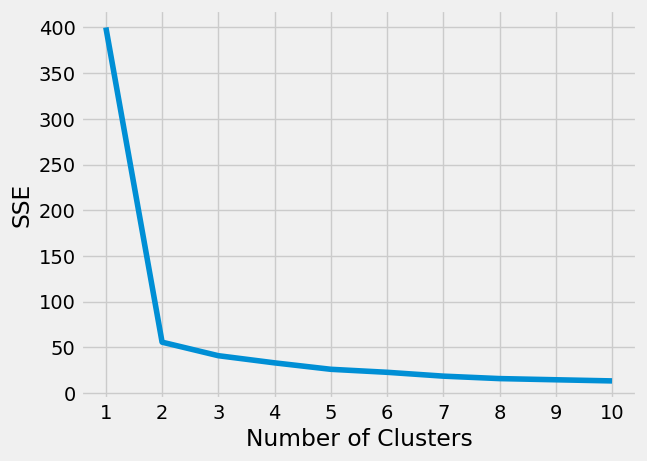

In [9]:
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)
    
plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

En este caso, es fácil notar en el número de clusters que el codo se encuentra en $k=2$, sin embargo para confirmar se puede hacer lo siguiente: 

In [10]:
kl = KneeLocator(
    range(1, 11), sse, curve="convex", direction="decreasing"
)

print(f"Knee elbow: {kl.elbow}")

Knee elbow: 2


#### 1.3.2 Coeficiente Silueta

Es una medida de la cohesión del cluster y su separación. Cuantifica como los datos se ajustan a un cluster basado en qué tan cerca están los datos a otros puntos en el cluster y la distancia entre el dato y aquellos de otro cluster. Para calcular el coeficiente se hace lo siguiente: 

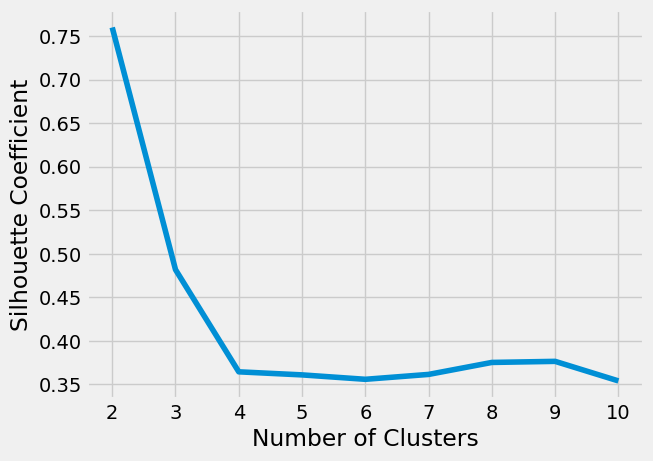

In [11]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_features)
    score = silhouette_score(scaled_features, kmeans.labels_)
    silhouette_coefficients.append(score)

plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

En este caso, se puede optar por usar $k=2$ debido a ser el máximo, pero también puede ser complicado trabajar con una cantidad demasiado baja de clusters. Por lo tanto, el uso de otro máximo local como $k=8$ o $k=9$ podría resultar útil para una segmentación granular. 

### 1.4 Evaluación de clusters con técnicas avanzadas

A veces vale la pena comparar con otro tipo de técnicas como se muestra a continuación.  

Inicialmente, se usa `make_moons()` para generar datos sintéticos en forma de lunas. 

In [12]:
features, true_labels = make_moons(
    n_samples=250, noise=0.05, random_state=42
)
scaled_features = scaler.fit_transform(features)

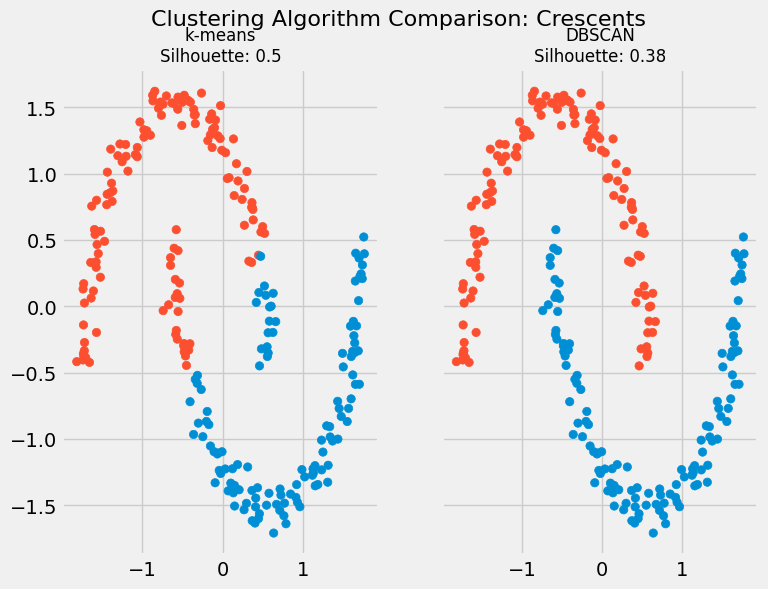

In [13]:
# instanciación de kmeans y dbscan
kmeans = KMeans(n_clusters=2)
dbscan = DBSCAN(eps=0.3)

# fit para cada uno
kmeans.fit(scaled_features)
dbscan.fit(scaled_features)

# silhouette para cada uno
kmeans_silhouette = silhouette_score(
    scaled_features, kmeans.labels_
).round(2)
dbscan_silhouette = silhouette_score(
   scaled_features, dbscan.labels_
).round (2)

# para visualizar 
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(8, 6), sharex=True, sharey=True
)
fig.suptitle(f"Clustering Algorithm Comparison: Crescents", fontsize=16)
fte_colors = {
    0: "#008fd5",
    1: "#fc4f30",
}

km_colors = [fte_colors[label] for label in kmeans.labels_]
ax1.scatter(scaled_features[:, 0], scaled_features[:, 1], c=km_colors)
ax1.set_title(
    f"k-means\nSilhouette: {kmeans_silhouette}", fontdict={"fontsize": 12}
)

db_colors = [fte_colors[label] for label in dbscan.labels_]
ax2.scatter(scaled_features[:, 0], scaled_features[:, 1], c=db_colors)
ax2.set_title(
    f"DBSCAN\nSilhouette: {dbscan_silhouette}", fontdict={"fontsize": 12}
)
plt.show()

Como ahora se conoceen los truth labels, ya se puede usar una métrica de clustering que considere etiquetas. Se puede usar la métrica de ARI, que utiliza asignaciones a true clusters para medir la similitud entre las etiquetas verdaderas y predichas. 

In [14]:
ari_kmeans = adjusted_rand_score(true_labels, kmeans.labels_)
ari_dbscan = adjusted_rand_score(true_labels, dbscan.labels_)
print(f"ARI kmeans: {round(ari_kmeans, 2)}")
print(f"ARI DBSCAN: {round(ari_dbscan, 2)}")

ARI kmeans: 0.46
ARI DBSCAN: 1.0


En este caso, el ARI de kmeans indica que se encuentra entre asignaciones aleatorias y perfectas, ligeramente más cercana a aleatorias. Mientras tanto para DBSCAN se identifica un etiquetado perfecto entre clusters.  

Finalmente, aquí concluye la sección de prueba y experimentación con los blobs de `make_blobs()`, lo cual otorga instrucciones claras, visualizaciones del funcionamiento de kmeans y métricas de evaluación para la validación del modelo.

## 2. Exploración de Datos 

Inicialmente, se realizará la exploración de datos que se mencionaron al inicio de la libreta, así como también la limpieza de los mismos. Inicialmente, se limpiarán los datos y posteriormente se utilizarán estrategias para manejar las variables categóricas e implementarlas en el modelo de K-Means.  
Primero se carga la base de datos: 

In [15]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
print("Dimensiones del dataset: ",df.shape)

Dimensiones del dataset:  (1200, 13)


Se identifican 1200 observaciones (filas) y 13 features (características) dentro del dataset. A continuación, se identifican NaNs en el dataset por columna y la suma total: 

In [16]:
print(f"NaNs por columna: \n{df.isna().sum()}")
print(f"Total de NaNs en el dataset: {df.isna().sum().sum()}")

NaNs por columna: 
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64
Total de NaNs en el dataset: 0


No se identificó ningún valor nulol. A continuación, se limpiará cualquier duplicado dentro del dataset en caso de existir: 

In [17]:
df = df.drop_duplicates()

Finalmente, el dataset se encuentra listo para maniobrar y realizar el proceso del *K-Means*.

## 3. Entrenamiento de Modelo

En esta sección, creamos el modelo `kmeans` con la librería de  `scikit-learn` y después con las features que se utilizan cruzarán el `StandardScaler()` para escalar los datos. Inicialmente, se determina que la variable a utilizar como `true_labels` para las métricas de evaluación más adelante es `social_interaction_level`, pues se puede categorizar a los adolescentes por su interacción con las demás personas y también relacionarlo al nivel de depresión que tiene cada uno. 

In [18]:
label_encoder = LabelEncoder()
true_labels = label_encoder.fit_transform(df['social_interaction_level'])
print(f"True labels para nivel de interacción: {true_labels[:5]}")
label_encoder.classes_
n_clusters = len(label_encoder.classes_)

True labels para nivel de interacción: [1 0 0 2 2]


Las demás variables formarán parte del conjunto `X` de datos mientras que `true_labels` será el valor `y`. Sin embargo, anticipadamente se identifican las variables numéricas y las categóricas: 
- numericas: `age`, `daily_social_media_hours`, `sleep_hours`, `screen_time_before_sleep`, `academic_performance`, `physical_activity`, `stress_level`, `anxiety_level`, `addiction_level`, `depression_label`
- categóricas: `gender`, `platform_usage`

Se omite `social_interaction_level` debido a que se utiliza como `true_labels`. 

Dado que `gender` es una variable binaria, se cambiarán los valores a 1 si es Hombre y 0 si es Mujer: 

In [19]:
df['gender'] = df['gender'].map({'male': 1, 'female': 0})

Y `platform_usage` por cuestiones de practicidad será no tomada en cuenta para este trabajo. A continuación, se muestra la división entre los valores de las columns correspondientes a `X` e `y`: 

In [20]:
X = df[['age', 'daily_social_media_hours', 'sleep_hours', 
        'screen_time_before_sleep', 'academic_performance', 
        'physical_activity', 'stress_level', 'anxiety_level', 
        'addiction_level']]

y = df['social_interaction_level']
true_label_names = y.copy()

A continuación, se crea una clase de PCA para realizar reducción de dimensionalidad dentro del Pipeloine de preprocesamiento de los datos. 

In [21]:
preprocessor = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        ("pca", PCA(n_components=2, random_state=42)),
    ]
)

A partir de aquí, construímos una pipeline separada para realizar clustering con k-means. Esto se muestra a continuación: 

In [22]:
clusterer = Pipeline(
   [
       (
           "kmeans",
           KMeans(
               n_clusters=n_clusters,
               init="k-means++",
               n_init=50,
               max_iter=500,
               random_state=42,
           ),
       ),
   ]
)

Finalmente, se pueden juntar ambas pipelines en una Pipeline masiva, que incluya ambos procesos: 

In [23]:
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("clusterer", clusterer)
    ]
)

En este caso, ya se incluye el preprocessor junto con el clusterer en la nueva Pipeline `pipe`, mediante la cual puedo llamar la función `fit` para ajustar finalmente los datos. 

In [24]:
pipe.fit(X)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', MinMaxScaler()),
                                 ('pca',
                                  PCA(n_components=2, random_state=42))])),
                ('clusterer',
                 Pipeline(steps=[('kmeans',
                                  KMeans(max_iter=500, n_clusters=3, n_init=50,
                                         random_state=42))]))])

## 4. Evaluación del Modelo

En esta sección, se plantea la evaluación de modelo a través del coefiicente silueta, el ARI y también visualizaciones de los clusters. 

In [25]:
preprocessed_data = pipe["preprocessor"].transform(X)
predicted_labels = pipe["clusterer"]["kmeans"].labels_
print(f"Coeficiente silueta: {silhouette_score(preprocessed_data, predicted_labels)}")

Coeficiente silueta: 0.35956082458599725


Se identifica un coeficiente silueta de ~0.36 que indica una baja calidad de los clusters. Adicionalmente, se calcula el ARI del modelo para ver si los clusters son similares a lo planteado por los `true_labels`: 

In [26]:
print(f"ARI: {adjusted_rand_score(true_labels, predicted_labels)}")

ARI: -0.0015797582318369157


El ARI resultó ser de ~-0.0016, lo cual es un valor extremadamente cercano a 0, por lo que indica que los clusters fueron asignados de manera aleatoria. 

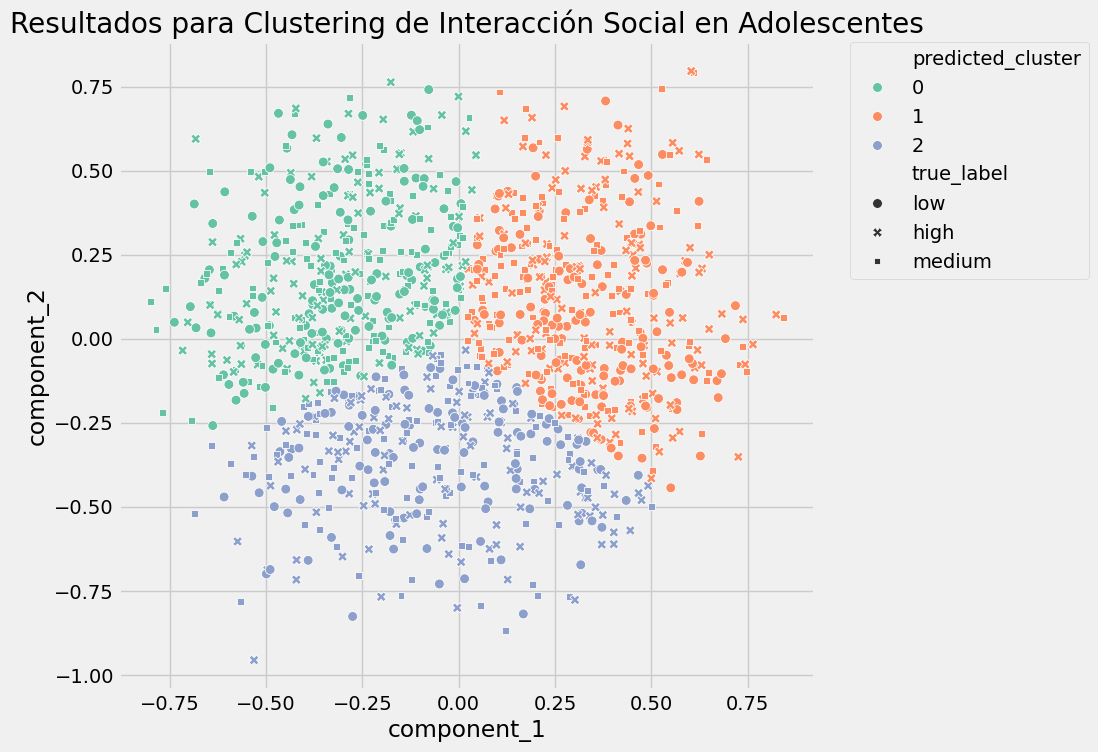

In [27]:
pcadf = pd.DataFrame(
    pipe["preprocessor"].transform(X),
    columns=["component_1", "component_2"],
)

pcadf["predicted_cluster"] = pipe["clusterer"]["kmeans"].labels_
pcadf["true_label"] = label_encoder.inverse_transform(true_labels)

plt.style.use("fivethirtyeight")
plt.figure(figsize=(8, 8))

scat = sns.scatterplot(
    x = "component_1",
    y = "component_2",
    s=50,
    data=pcadf,
    hue="predicted_cluster",
    style="true_label",
    palette="Set2",
)

scat.set_title(
    "Resultados para Clustering de Interacción Social en Adolescentes"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

plt.show()

En esta visualización, los diferentes tipos de figuras se ven demasiado dispersos, pues no siguen algún patron relevante en su posición como para poder clusterear de mejor manera. Los colores se dividen por posición dentro del plano pero aparentemente la interacción social de los adolescentes no se centra en eso. 

## 5. Mejora del Modelo

En esta seccion, se trabaja con modificaciones dentro de las distintas funciones y modelos utilizados con el objetivo de mejorar la calidad del KMeans.  
En el siguiente ejemplo, se utilizarán metricas de performance de clustering para identificar el número apropiado de componentes para PCA, lo que permite reducir dimensiones. 

In [30]:
# Empty lists to hold evaluation metrics
silhouette_scores = []
ari_scores = []

# Ensure n_components does not exceed min(n_samples, n_features)
max_components = min(X.shape[0], X.shape[1])

for n in range(2, max_components + 1):  # Adjust range to valid n_components
    # Update the number of components for PCA using set_params
    pipe.set_params(preprocessor__pca__n_components=n)
    pipe.fit(X)

    # Calculate silhouette score
    silhouette_coef = silhouette_score(
        pipe["preprocessor"].transform(X),
        pipe["clusterer"]["kmeans"].labels_,
    )
    # Calculate adjusted rand index
    ari = adjusted_rand_score(
        true_labels,
        pipe["clusterer"]["kmeans"].labels_,
    )

    # Add metrics to their lists
    silhouette_scores.append(silhouette_coef)
    ari_scores.append(ari)

Finalmente, se plantean las siguientes visualizaciones. 

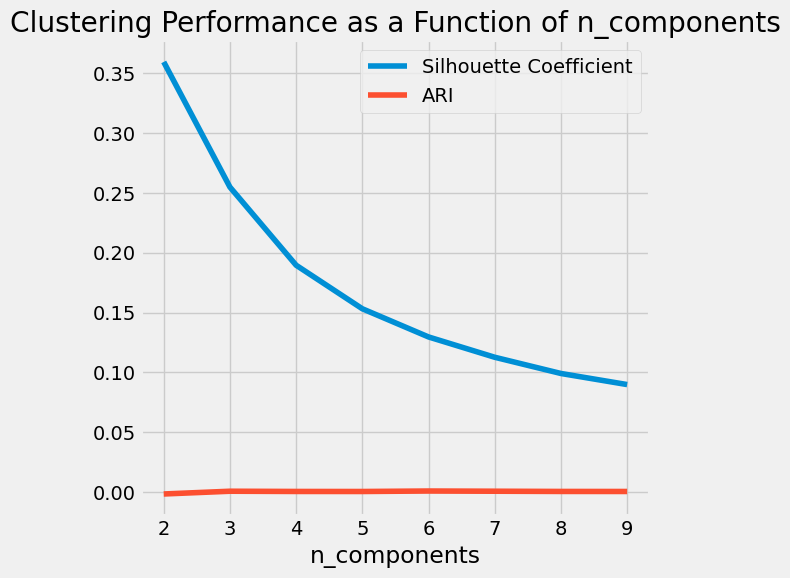

In [32]:
plt.style.use("fivethirtyeight")
plt.figure(figsize=(6, 6))

# Use the correct range based on the length of the scores
n_components_range = range(2, len(silhouette_scores) + 2)

plt.plot(
    n_components_range,
    silhouette_scores,
    c="#008fd5",
    label="Silhouette Coefficient",
)
plt.plot(
    n_components_range,
    ari_scores,
    c="#fc4f30",
    label="ARI",
)

plt.xlabel("n_components")
plt.legend()
plt.title("Clustering Performance as a Function of n_components")
plt.tight_layout()
plt.show()

En la gráfica se visualiza el coeficiente de silueta y el ARI; cada uno representa algo diferente: 
- El coeficiente silueta va de bajada.l Su punto máximo es 0.36 y de ahí disminuye. A medida que se busca forzar más divisiones, los grupos se enciman y pierden claridad entre ellos. 
- El ARI indica que la agrupación que realiza el modelo no es mejor que alguna aleatoria, por lo que no coincide con las separaciones que se esperan (en este caso, los niveles de interacción social de los adolescentes). 

## 6. Reflexión 

A lo largo de esta actividad, profundicé en el funcionamiento de K-Means partiendo del ejemplo con `make_blobs`, lo cual fue clave para entender cómo el algoritmo minimiza el SSE (*Sum of Squared Errors*) reasignando puntos a centroides iterativamente hasta converger. Este ejercicio previo fue esencial antes de aplicarlo a datos reales, pues permitió experimentar con hiperparámetros como `n_init` y `max_iter` en un entorno controlado.

Uno de los retos principales fue la elección del dataset: para calcular el ARI se requieren `true_labels`, algo poco común en contextos de aprendizaje no supervisado. Otro reto fue la construcción de `Pipelines`, que encadenan `MinMaxScaler` -> `PCA` -> `KMeans` garantizando que las transformaciones se apliquen en orden correcto y evitando *data leakage*. Aunque inicialmente resultó confusa, `set_params()` demostró ser muy útil al permitir modificar hiperparámetros internos del pipeline sin reconstruirlo, como al barrer distintos valores de `n_components` en PCA.

La comparación entre K-Means y DBSCAN con datos `make_moons` fue de las partes más ilustrativas: K-Means falló al asumir clusters esféricos y convexos, mientras DBSCAN capturó perfectamente la geometría no convexa, obteniendo un ARI de 1.0 frente al valor cercano a 0 de K-Means. Las visualizaciones en general fueron la parte más enriquecedora, ya que concretizan algo que en teoría puede volverse abstracto.

Finalmente, el ARI ≈ -0.0016 y la silueta ≈ 0.36 obtenidos en el modelo final no representan un fallo sino un hallazgo técnico válido: K-Means encontró sus propias particiones geométricas en el espacio de features que no se alinean con los niveles de `social_interaction_level`. Esto sugiere que dicha variable no es recuperable de forma no supervisada con las features numéricas seleccionadas, y que variables descartadas como `platform_usage` podrían haber aportado mayor poder discriminativo.